In [1]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/access_token', 'w') as f:
    f.write('KGAT_915b67ffe0c530f039e4e6f124b00113')  # paste the KGAT_... string here, inside the quotes

os.chmod('/root/.kaggle/access_token', 0o600)

print("Token saved!")

Token saved!


In [2]:
!pip install -q kaggle

In [3]:
!kaggle datasets download -d anikannal/solar-power-generation-data

Dataset URL: https://www.kaggle.com/datasets/anikannal/solar-power-generation-data
License(s): copyright-authors
100% 1.90M/1.90M [00:00<00:00, 158MB/s]



## 1. Dataset
Using the "Solar Power Generation Data" dataset from Kaggle, which contains 34 days of data from two solar power plants — generation data (DC/AC power, yield) from individual inverters, and weather sensor data (irradiation, ambient temperature, module temperature).

In [4]:
import zipfile

with zipfile.ZipFile('solar-power-generation-data.zip', 'r') as zip_ref:
    zip_ref.extractall('solar_data')

print("Unzipped successfully!")

Unzipped successfully!


In [5]:
import os
os.listdir('solar_data')

['Plant_1_Weather_Sensor_Data.csv',
 'Plant_1_Generation_Data.csv',
 'Plant_2_Generation_Data.csv',
 'Plant_2_Weather_Sensor_Data.csv']

## 2. Loading & Understanding the Data
Generation data has ~68,778 rows (22 inverters × timestamps), while weather data has only ~3,182 rows (1 sensor × timestamps). This mismatch is expected — each plant has one weather sensor but many inverters.

In [6]:
import pandas as pd

gen_data = pd.read_csv('solar_data/Plant_1_Generation_Data.csv')
weather_data = pd.read_csv('solar_data/Plant_1_Weather_Sensor_Data.csv')

print("Generation Data shape:", gen_data.shape)
print("Weather Data shape:", weather_data.shape)

gen_data.head()

Generation Data shape: (68778, 7)
Weather Data shape: (3182, 6)


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [7]:
weather_data.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


## 3. Merging Datasets
Merging generation and weather data on `DATE_TIME` and `PLANT_ID` so each inverter reading has its corresponding weather conditions at that timestamp.

In [8]:
# Convert DATE_TIME to proper datetime format
gen_data['DATE_TIME'] = pd.to_datetime(gen_data['DATE_TIME'], format='%d-%m-%Y %H:%M')
weather_data['DATE_TIME'] = pd.to_datetime(weather_data['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Merge on DATE_TIME and PLANT_ID
merged_df = pd.merge(gen_data, weather_data, on=['DATE_TIME', 'PLANT_ID'], suffixes=('_gen', '_weather'))

print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (68774, 11)


,DATE_TIME,PLANT_ID,SOURCE_KEY_gen,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_weather,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


## 4. Exploratory Data Analysis
Visualizing the relationship between AC Power and each weather feature. Irradiation shows the strongest, most linear correlation with power output — consistent with the physics of photovoltaic generation.

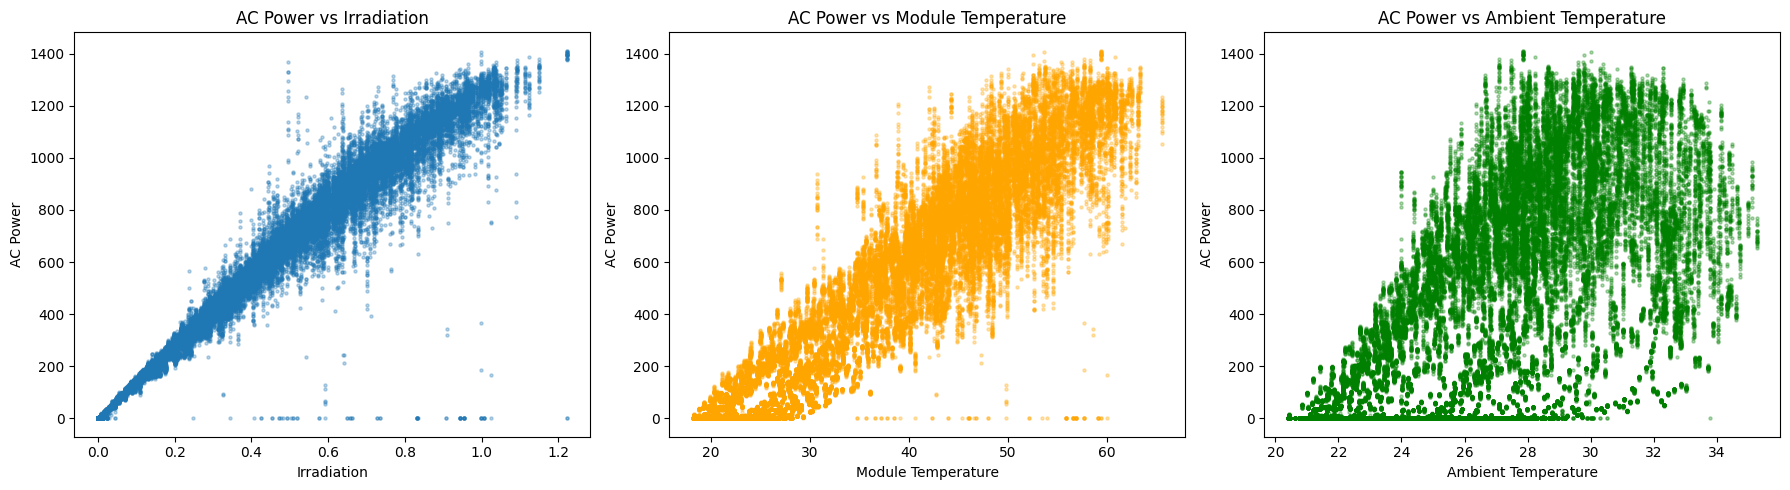

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(merged_df['IRRADIATION'], merged_df['AC_POWER'], alpha=0.3, s=5)
axes[0].set_xlabel('Irradiation')
axes[0].set_ylabel('AC Power')
axes[0].set_title('AC Power vs Irradiation')

axes[1].scatter(merged_df['MODULE_TEMPERATURE'], merged_df['AC_POWER'], alpha=0.3, s=5, color='orange')
axes[1].set_xlabel('Module Temperature')
axes[1].set_ylabel('AC Power')
axes[1].set_title('AC Power vs Module Temperature')

axes[2].scatter(merged_df['AMBIENT_TEMPERATURE'], merged_df['AC_POWER'], alpha=0.3, s=5, color='green')
axes[2].set_xlabel('Ambient Temperature')
axes[2].set_ylabel('AC Power')
axes[2].set_title('AC Power vs Ambient Temperature')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

features = ['IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE']
X = merged_df[features]
y = merged_df['AC_POWER']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (55019, 3)
Testing set size: (13755, 3)


## 5. Train-Test Split
Splitting data 80/20 to evaluate model performance on unseen data.

## 6. Baseline Model — Linear Regression
Starting with a simple linear model to establish a performance baseline.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 55.51243762482287
R² Score: 0.9800288894346423


## 7. Random Forest Regressor
Testing an ensemble model to capture any non-linear relationships (e.g., temperature's effect on panel efficiency) that linear regression might miss.

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R² Score:", r2_rf)

Random Forest RMSE: 45.66977574902308
Random Forest R² Score: 0.9864830291297274


In [13]:
importances = rf_model.feature_importances_
for feature, importance in zip(features, importances):
    print(f"{feature}: {importance:.4f}")

IRRADIATION: 0.9965
MODULE_TEMPERATURE: 0.0021
AMBIENT_TEMPERATURE: 0.0015


## 8. Feature Importance & Model Evaluation
Analyzing which features the Random Forest relied on most, and visualizing predicted vs actual power to assess overall model accuracy.

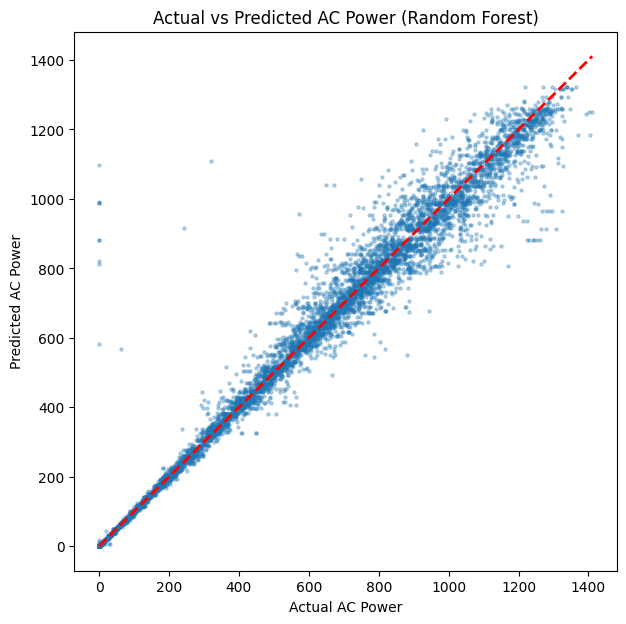

In [14]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_rf, alpha=0.3, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.title('Actual vs Predicted AC Power (Random Forest)')
plt.show()